# Chapter 9: CNN for Time Series Patterns
### Pattern-Based Forecasting with Real Data

## Introduction
In this notebook, we implement a Convolutional Neural Network (CNN) for time series forecasting using real stock data.

We will:
- Load real-world stock data
- Preprocess and normalize it
- Convert it into sequences (windowing)
- Build a CNN model
- Train and evaluate predictions

The goal is to learn **local patterns** in time series data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense

## Step 1: Load Data
We download Apple stock price data and visualize it.


/tmp/ipykernel_639/1773879066.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


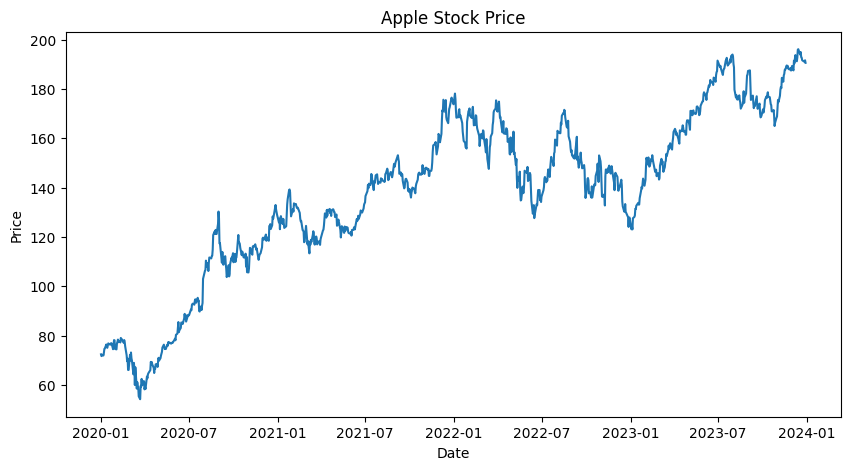

In [2]:
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
prices = data['Close']

plt.figure(figsize=(10,5))
plt.plot(prices)
plt.title("Apple Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Step 2: Normalize Data
Scaling data between 0 and 1 improves neural network performance.


In [3]:
scaler = MinMaxScaler()
scaled_prices = scaler.fit_transform(prices.values.reshape(-1,1))

## Step 3: Create Sequences (Windowing)
We convert the time series into input-output pairs.


In [4]:
def create_sequences(data, window_size=20):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_prices, 20)

## Step 4: Train-Test Split
We split data into training and testing sets.


In [5]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Step 5: Build CNN Model
We define a CNN architecture for pattern detection.


In [6]:
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(20,1)))
model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        28,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,157 (113.89 KB)

 Trainable params: 29,157 (113.89 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train Model
The model learns patterns over multiple epochs.


In [7]:
history = model.fit(X_train, y_train, epochs=10, batch_size=16)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0162
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0011
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7647e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.1772e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7476e-04
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010    
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.9135e-04


## Step 7: Predictions
We generate predictions and convert them back to original scale.


In [8]:
predictions = model.predict(X_test)

predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


## Step 8: Visualization
Compare predicted vs actual values.


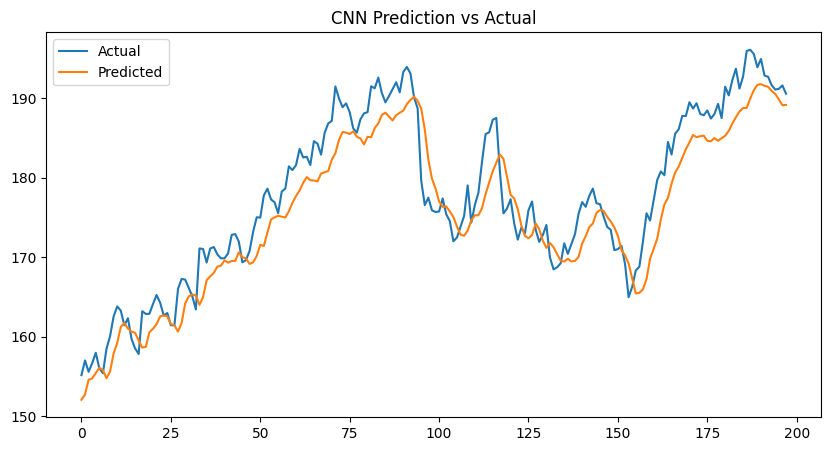

In [9]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label='Actual')
plt.plot(predicted_prices, label='Predicted')
plt.legend()
plt.title("CNN Prediction vs Actual")
plt.show()